In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import scipy
import sklearn
from sklearn.svm import SVC
from scipy.stats import pearsonr
from sklearn import datasets, linear_model
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,  RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import loguniform

#!pip install xlrd 
#!pip install category_encoders
import category_encoders as ce



In [33]:
df = pd.read_excel("TrainDataset2025.xls")
df.head()

0      1
1      0
2      1
3      1
4      1
      ..
395    0
396    0
397    0
398    0
399    0
Name: Gene, Length: 400, dtype: int64

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 121 entries, ID to original_ngtdm_Strength
dtypes: float64(108), int64(12), object(1)
memory usage: 378.3+ KB


,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,HistologyType,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,...,4.000000e+02,4.000000e+02,4.000000e+02,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000
mean,12.697500,56.000208,51.804674,0.547500,2.902500,2.797500,2.830000,9.875000,6.562500,8.63250,...,3.957637e-01,3.911005e-01,2.722189e+00,0.003347,5.679717e+07,178.311246,32500.032620,0.056935,0.005965,0.029322
std,111.107417,27.137584,10.948522,0.498362,49.932114,49.937068,49.935558,86.092911,70.444284,86.20034,...,1.666319e-01,1.615922e-01,7.648849e-01,0.002419,7.063846e+08,1045.453432,177545.921568,0.047179,0.008379,0.115915
min,0.000000,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,...,7.050000e-11,7.050000e-11,-3.200000e-16,0.000008,0.000000e+00,0.000000,0.000248,0.000000,0.000000,0.000000
25%,0.000000,38.000000,44.516769,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,3.199017e-01,3.184398e-01,2.340783e+00,0.001389,1.030473e+06,18.760570,0.001826,0.018628,0.000310,0.001464
50%,0.000000,55.000000,51.019507,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,4.095627e-01,4.054695e-01,2.814884e+00,0.002944,3.277334e+06,67.929659,0.004383,0.047740,0.002330,0.003276
75%,0.000000,73.000000,60.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.00000,...,5.000049e-01,4.956920e-01,3.304411e+00,0.004798,9.079686e+06,157.370294,0.013769,0.085321,0.007962,0.009479
max,999.000000,144.000000,79.603012,1.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000,...,8.773779e-01,8.571429e-01,4.947427e+00,0.011301,1.390001e+10,20764.693790,1000000.000000,0.285100,0.060742,1.145601


In [4]:
df.replace(999, pd.NA, inplace=True)

In [5]:
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]
missing_cols

pCR (outcome)       5
PgR                 1
HER2                1
TrippleNegative     1
ChemoGrade          3
Proliferation       2
HistologyType       3
LNStatus            1
Gene               88
dtype: int64

In [6]:
# Get columns with missing values
missing_cols = df.columns[df.isna().any()]

# Missing data summary
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df[col].isna().sum() for col in missing_cols],
    'Dtype': [df[col].dtype for col in missing_cols]
})

print(summary)

            Column  MissingCount   Dtype
0    pCR (outcome)             5  object
1              PgR             1  object
2             HER2             1  object
3  TrippleNegative             1  object
4       ChemoGrade             3  object
5    Proliferation             2  object
6    HistologyType             3  object
7         LNStatus             1  object
8             Gene            88  object


In [7]:
df_dropped =  df.dropna(subset=['pCR (outcome)'])
df_dropped = df_dropped.drop("RelapseFreeSurvival (outcome)", axis=1)
df_dropped.shape

(395, 120)

In [8]:
missing_cols = df_dropped.columns[df_dropped.isna().any()]
# Missing data summary
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df_dropped[col].isna().sum() for col in missing_cols],
    'Dtype': [df_dropped[col].dtype for col in missing_cols]
})

print(summary)

            Column  MissingCount   Dtype
0              PgR             1  object
1             HER2             1  object
2  TrippleNegative             1  object
3       ChemoGrade             3  object
4    Proliferation             2  object
5    HistologyType             3  object
6         LNStatus             1  object
7             Gene            85  object


In [9]:
# Iterative imputation

df_imputed = df_dropped.copy()

# Select categorical columns
cat_columns = df_imputed.select_dtypes(include=['object', 'category']).columns
cat_cols_to_encode = cat_columns.drop('pCR (outcome)')

encoder = ce.OrdinalEncoder(handle_missing='return_nan') 


# Encode categorical features
df_imputed[cat_cols_to_encode] = encoder.fit_transform(df_imputed[cat_cols_to_encode])


## Imputation with IterativeImputer
# Separate target
y_target = df_imputed['pCR (outcome)']
X_features = df_imputed.drop(columns=['pCR (outcome)'])

# Iterative Imputer
imputer = IterativeImputer(max_iter=20, random_state=42)
X_imputed = imputer.fit_transform(X_features)

# Convert back to DataFrame
X_imputed_df = pd.DataFrame(X_imputed,
                            columns=X_features.columns,
                            index=X_features.index)

# Round encoded categorical columns back to integers
for col in cat_cols_to_encode:
    max_val = df_imputed[col].max()
    min_val = df_imputed[col].min()
    X_imputed_df[col] = X_imputed_df[col].clip(lower=min_val, upper=max_val)
    X_imputed_df[col] = X_imputed_df[col].round().astype(int)

    
# Inverse transform encoded categorical columns
X_imputed_df[cat_cols_to_encode] = encoder.inverse_transform(X_imputed_df[cat_cols_to_encode])


# Recombine target
final_df = pd.concat([X_imputed_df, y_target], axis=1)
final_df = final_df[sorted(final_df.columns)]
print("\n--- Missing Value Check ---")
print(final_df.isna().sum())


--- Missing Value Check ---
Age                                  0
ChemoGrade                           0
ER                                   0
Gene                                 0
HER2                                 0
                                    ..
original_shape_Sphericity            0
original_shape_SurfaceArea           0
original_shape_SurfaceVolumeRatio    0
original_shape_VoxelVolume           0
pCR (outcome)                        0
Length: 120, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# -----------------------------
# Build X, y
# -----------------------------
y = final_df["pCR (outcome)"].astype(int)
X = final_df.drop(["pCR (outcome)", "ID"], axis=1)

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

#print("Number of numeric features:", len(num_features))
#print("Categorical features:", cat_features)

# Train / test split (hold out 30% for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


In [11]:
# Preprocessing and Feature Selection
'''
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Preprocess: scale numeric, one-hot encode categoricals
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)
'''


In [50]:
keep_cats = 
other_cats = [c for c in cat_features if c not in keep_cats]

keep_preprocess = ColumnTransformer(
    transformers=[
        ("keep_cat", OneHotEncoder(handle_unknown="ignore"), keep_cats),
    ],
    remainder="drop"
)

other_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), other_cats),
    ],
    remainder="drop"
)

rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ),
    threshold="median", # mean  
)


In [58]:
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from scipy.stats import loguniform

# Features = [ER/HER2/Gene one-hot] + [RF-selected other features]
full_features = FeatureUnion([
    ("always_keep", keep_preprocess),
    ("rf_selected", Pipeline([
        ("prep", other_preprocess),
        ("select", rf_selector),
    ])),
])

svm_pipe = Pipeline(steps=[
    ("features", full_features),
    ("svm", SVC(kernel="rbf", probability=False)),
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42,
)

param_dist = {
    "svm__C": loguniform(1e-4, 1e4),
    "svm__gamma": loguniform(1e-4, 1e1),
    "svm__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)


search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)

best_svm = search.best_estimator_


Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'svm__C': 0.09915644566638401, 'svm__class_weight': None, 'svm__gamma': 0.0008263688714158015}
Best CV ROC AUC: 0.6856830994938816


In [12]:
'''
# Random Forest used as feature selector
rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"  # helps with pCR imbalance
    ),
    threshold="median"   # keep features with importance above median, can also try mean
)
'''

In [22]:
'''
# SVM Pipeline and Hyperparameter Search
from scipy.stats import loguniform
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV

# Full pipeline: preprocessing -> RF feature selection -> SVM
svm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("select", rf_selector),
    ("svm", SVC(kernel="rbf", probability=False))
])

# Repeated stratified CV – good for small, imbalanced datasets
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

# Hyperparameter search space
param_dist = {
    "svm__C": loguniform(1e-3, 1e3),
    "svm__gamma": loguniform(1e-4, 1e1),
    "svm__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=50,              # can increase if compute allows
    cv=cv,
    scoring="roc_auc",      # key metric for this task
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)

best_svm = search.best_estimator_
comments = 
Do the best C and gamma sit near the edges of your search range?
If yes, extend the range (e.g. 1e-4 to 1e4).
'''

Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'svm__C': 0.1767016940294795, 'svm__class_weight': None, 'svm__gamma': 0.0008263688714158015}
Best CV ROC AUC: 0.6634699532321097


In [52]:
# Evaluation of Model
# Fit best pipeline on full training set
best_svm.fit(X_train, y_train)

# Decision scores on test set
scores_test = best_svm.decision_function(X_test)  # continuous margins
y_pred_default = best_svm.predict(X_test)

# Basic metrics with default decision threshold
roc_auc = roc_auc_score(y_test, scores_test)
pr_auc = average_precision_score(y_test, scores_test)  # PR AUC
bal_acc = balanced_accuracy_score(y_test, y_pred_default)

print("Test ROC AUC:",e roc_auc)
print("Test PR AUC:", pr_auc)
print("Test balanced accuracy:", bal_acc)
print("Confusion matrix (default threshold):\n", confusion_matrix(y_test, y_pred_default))
print("Classification report (default threshold):\n", classification_report(y_test, y_pred_default))


Test ROC AUC: 0.7638297872340426
Test PR AUC: 0.5205332717241044
Test balanced accuracy: 0.7257446808510639
Confusion matrix (default threshold):
 [[65 29]
 [ 6 19]]
Classification report (default threshold):
               precision    recall  f1-score   support

           0       0.92      0.69      0.79        94
           1       0.40      0.76      0.52        25

    accuracy                           0.71       119
   macro avg       0.66      0.73      0.65       119
weighted avg       0.81      0.71      0.73       119



In [40]:
preprocessor = best_svm.named_steps["preprocess"]
selector = best_svm.named_steps["select"]

# Names of all features *after* preprocessing (including one-hot columns)
all_feature_names = preprocessor.get_feature_names_out()
#print(all_feature_names)
print("Total transformed features:", len(all_feature_names))

KeyError: 'preprocess'

In [32]:
mask = selector.get_support()  # True = selected, False = dropped
selected_features = np.array(all_feature_names)[mask]
dropped_features  = np.array(all_feature_names)[~mask]

print("Selected features:", len(selected_features))
print("Dropped features:", len(dropped_features))

print("Some selected features:")
for f in selected_features[:20]:
    print("  ", f)

print("\nSome dropped features:")
for f in dropped_features[:20]:
    print("  ", f)


Selected features: 64
Dropped features: 64
Some selected features:
   num__ER
   num__original_firstorder_10Percentile
   num__original_firstorder_90Percentile
   num__original_firstorder_Energy
   num__original_firstorder_InterquartileRange
   num__original_firstorder_Kurtosis
   num__original_firstorder_Maximum
   num__original_firstorder_Mean
   num__original_firstorder_Median
   num__original_firstorder_Minimum
   num__original_firstorder_Range
   num__original_firstorder_RootMeanSquared
   num__original_firstorder_Skewness
   num__original_firstorder_TotalEnergy
   num__original_firstorder_Variance
   num__original_glcm_Imc1
   num__original_gldm_DependenceEntropy
   num__original_gldm_DependenceNonUniformity
   num__original_gldm_DependenceNonUniformityNormalized
   num__original_gldm_GrayLevelNonUniformity

Some dropped features:
   num__Age
   num__TumourStage
   num__original_firstorder_Entropy
   num__original_firstorder_MeanAbsoluteDeviation
   num__original_firstorder_Robus

Best threshold by balanced accuracy: -0.21980633813280415
Balanced accuracy at this threshold: 0.7404255319148936
Sensitivity (recall for pCR=1): 0.8
Specificity: 0.6808510638297872
Confusion matrix (best threshold):
 [[64 30]
 [ 5 20]]
Classification report (best threshold):
               precision    recall  f1-score   support

           0       0.93      0.68      0.79        94
           1       0.40      0.80      0.53        25

    accuracy                           0.71       119
   macro avg       0.66      0.74      0.66       119
weighted avg       0.82      0.71      0.73       119



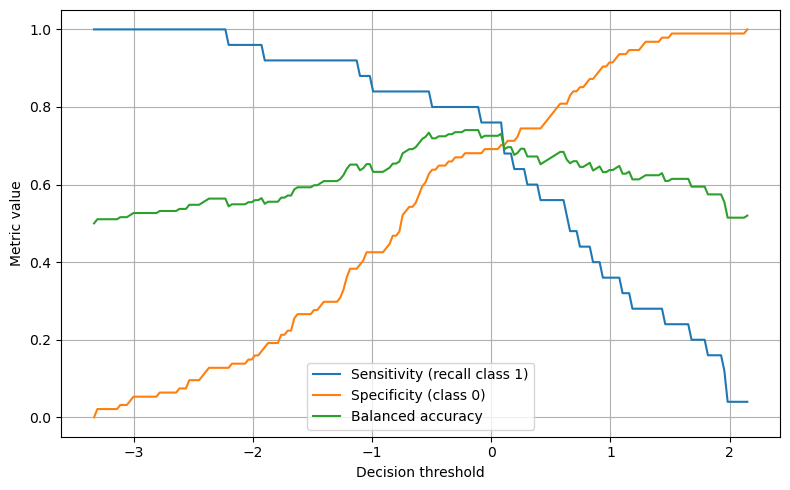

In [53]:
# Threshold tuning
import matplotlib.pyplot as plt

# Compute ROC and PR curves
fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
prec, rec, pr_thresholds = precision_recall_curve(y_test, scores_test)

# Example: try a grid of thresholds and compute metrics
thresholds = np.linspace(scores_test.min(), scores_test.max(), 200)

results = []
for thr in thresholds:
    y_pred_thr = (scores_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    
    # Avoid division by zero
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall for pCR=1
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # specificity
    bal_acc_thr = 0.5 * (sens + spec)
    
    results.append((thr, sens, spec, bal_acc_thr))

thr_arr = np.array([r[0] for r in results])
sens_arr = np.array([r[1] for r in results])
spec_arr = np.array([r[2] for r in results])
bal_arr  = np.array([r[3] for r in results])

# Example: pick the threshold that maximises balanced accuracy
best_idx = np.argmax(bal_arr)
best_thr = thr_arr[best_idx]
print("Best threshold by balanced accuracy:", best_thr)
print("Balanced accuracy at this threshold:", bal_arr[best_idx])
print("Sensitivity (recall for pCR=1):", sens_arr[best_idx])
print("Specificity:", spec_arr[best_idx])

# Predictions with best threshold
y_pred_best = (scores_test >= best_thr).astype(int)
print("Confusion matrix (best threshold):\n", confusion_matrix(y_test, y_pred_best))
print("Classification report (best threshold):\n", classification_report(y_test, y_pred_best))

# Optional: visualise sensitivity and specificity vs threshold
plt.figure(figsize=(8, 5))
plt.plot(thr_arr, sens_arr, label="Sensitivity (recall class 1)")
plt.plot(thr_arr, spec_arr, label="Specificity (class 0)")
plt.plot(thr_arr, bal_arr, label="Balanced accuracy")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [54]:
final_model = {
    "pipeline": best_svm,
    "threshold": best_thr
}


In [56]:
def svm_predict(X_test):
    scores_test = final_model["pipeline"].decision_function(X_test)  # continuous margins
    y_pred_default = final_model["pipeline"].predict(X_test)
    y_pred_best = (scores_test >= best_thr).astype(int)
    return y_pred_best

In [57]:
svm_predict(X_test)

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1])